In [1]:
import subprocess
import sys

# Install required libraries
print("Installing required libraries...\n")

libraries = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'tensorflow',
    'librosa'
]

for lib in libraries:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', lib])
        print(f"✓ {lib} installed successfully")
    except Exception as e:
        print(f"✗ Error installing {lib}: {e}")

print("\n✓ All libraries installed!\n")

Installing required libraries...

✓ pandas installed successfully
✓ numpy installed successfully
✓ matplotlib installed successfully
✓ seaborn installed successfully
✓ scikit-learn installed successfully
✓ tensorflow installed successfully
✓ librosa installed successfully

✓ All libraries installed!



# Klasifikasi Musik dengan CNN (Multiple Feature Combinations)

Notebook ini melatih dan membandingkan **7 model CNN** dengan berbagai kombinasi fitur audio:

## 🎵 7 Feature Combinations:
1. **Model 1**: MFCC saja (26 features)
2. **Model 2**: Chroma saja (72 features)
3. **Model 3**: Mel Spectrogram saja (512 features)
4. **Model 4**: MFCC + Chroma (98 features)
5. **Model 5**: MFCC + Mel Spectrogram (538 features)
6. **Model 6**: Chroma + Mel Spectrogram (584 features)
7. **Model 7**: MFCC + Chroma + Mel Spectrogram (610 features) - **FULL**

## 📊 Workflow:
- Load & normalize features dari CSV
- Build CNN models dengan fixed architecture
- Train semua models dengan hyperparameter yang sama
- Generate confusion matrices untuk setiap model
- Bandingkan akurasi, F1-score, dan performa per genre
- Visualisasi hasil perbandingan

## 1. Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import time

warnings.filterwarnings('ignore')

# Set random seeds untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

# Load CSV data
print("\n" + "="*80)
print("LOADING DATA FROM CSV")
print("="*80)

mfcc_df = pd.read_csv('extracted_features_mfcc.csv')
mel_spec_df = pd.read_csv('extracted_features_mel_spectrogram.csv')
chroma_df = pd.read_csv('extracted_features_chroma.csv')

print(f"✓ MFCC shape: {mfcc_df.shape}")
print(f"✓ Mel Spectrogram shape: {mel_spec_df.shape}")
print(f"✓ Chroma shape: {chroma_df.shape}")

# Extract feature columns
mfcc_cols = [col for col in mfcc_df.columns if 'mfcc' in col and col not in ['genre', 'filename']]
mel_cols = [col for col in mel_spec_df.columns if 'mel' in col and col not in ['genre', 'filename']]
chroma_cols = [col for col in chroma_df.columns if 'chroma' in col and col not in ['genre', 'filename']]

print(f"\n→ Feature Counts:")
print(f"  MFCC: {len(mfcc_cols)} features")
print(f"  Mel Spectrogram: {len(mel_cols)} features")
print(f"  Chroma: {len(chroma_cols)} features")

# Get labels
y = mfcc_df['genre'].values
genres = np.unique(y)
print(f"\n→ Genres: {', '.join(genres)}")
print(f"  Total genres: {len(genres)}")
print(f"  Total samples: {len(y)}")

✓ All libraries imported successfully
TensorFlow version: 2.21.0
NumPy version: 2.4.4

LOADING DATA FROM CSV
✓ MFCC shape: (999, 28)
✓ Mel Spectrogram shape: (999, 513)
✓ Chroma shape: (999, 73)

→ Feature Counts:
  MFCC: 26 features
  Mel Spectrogram: 512 features
  Chroma: 72 features

→ Genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, rock
  Total genres: 10
  Total samples: 999


## 2. Feature Extraction & Normalization

In [3]:
print("\n" + "="*80)
print("FEATURE EXTRACTION & NORMALIZATION")
print("="*80)

# Extract feature values
mfcc_values = mfcc_df[mfcc_cols].values
mel_values = mel_spec_df[mel_cols].values
chroma_values = chroma_df[chroma_cols].values

print(f"\n→ Raw feature shapes:")
print(f"  MFCC: {mfcc_values.shape}")
print(f"  Mel: {mel_values.shape}")
print(f"  Chroma: {chroma_values.shape}")

# Normalize features
print(f"\n→ Normalizing features (StandardScaler)...")

scaler_mfcc = StandardScaler()
mfcc_scaled = scaler_mfcc.fit_transform(mfcc_values)

scaler_mel = StandardScaler()
mel_scaled = scaler_mel.fit_transform(mel_values)

scaler_chroma = StandardScaler()
chroma_scaled = scaler_chroma.fit_transform(chroma_values)

print(f"  ✓ MFCC normalized")
print(f"  ✓ Mel Spectrogram normalized")
print(f"  ✓ Chroma normalized")

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=len(genres))

print(f"\n→ Labels encoded:")
print(f"  Classes: {le.classes_}")
print(f"  Encoded shape: {y_categorical.shape}")

# Train-test split
print(f"\n→ Splitting data (80% train, 20% test)...")
X_train_mfcc, X_test_mfcc, y_train, y_test = train_test_split(
    mfcc_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train_mel, X_test_mel, _, _ = train_test_split(
    mel_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train_chroma, X_test_chroma, _, _ = train_test_split(
    chroma_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"  Train set size: {X_train_mfcc.shape[0]}")
print(f"  Test set size: {X_test_mfcc.shape[0]}")

# Create 7 feature combinations
print(f"\n→ Creating 7 feature combinations...")

feature_combinations = {
    'MFCC only': np.concatenate([X_train_mfcc, X_train_mfcc], axis=0)[:X_train_mfcc.shape[0]],
    'Chroma only': np.concatenate([X_train_chroma, X_train_chroma], axis=0)[:X_train_chroma.shape[0]],
    'Mel only': np.concatenate([X_train_mel, X_train_mel], axis=0)[:X_train_mel.shape[0]],
    'MFCC + Chroma': np.concatenate([X_train_mfcc, X_train_chroma], axis=1),
    'MFCC + Mel': np.concatenate([X_train_mfcc, X_train_mel], axis=1),
    'Chroma + Mel': np.concatenate([X_train_chroma, X_train_mel], axis=1),
    'MFCC + Chroma + Mel': np.concatenate([X_train_mfcc, X_train_chroma, X_train_mel], axis=1)
}

test_combinations = {
    'MFCC only': X_test_mfcc,
    'Chroma only': X_test_chroma,
    'Mel only': X_test_mel,
    'MFCC + Chroma': np.concatenate([X_test_mfcc, X_test_chroma], axis=1),
    'MFCC + Mel': np.concatenate([X_test_mfcc, X_test_mel], axis=1),
    'Chroma + Mel': np.concatenate([X_test_chroma, X_test_mel], axis=1),
    'MFCC + Chroma + Mel': np.concatenate([X_test_mfcc, X_test_chroma, X_test_mel], axis=1)
}

print(f"\n  Feature combination shapes:")
for name, X in feature_combinations.items():
    print(f"  • {name:25} → {X.shape}")

print(f"\n✓ Data preparation completed!")


FEATURE EXTRACTION & NORMALIZATION

→ Raw feature shapes:
  MFCC: (999, 26)
  Mel: (999, 512)
  Chroma: (999, 72)

→ Normalizing features (StandardScaler)...
  ✓ MFCC normalized
  ✓ Mel Spectrogram normalized
  ✓ Chroma normalized

→ Labels encoded:
  Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
  Encoded shape: (999, 10)

→ Splitting data (80% train, 20% test)...
  Train set size: 799
  Test set size: 200

→ Creating 7 feature combinations...

  Feature combination shapes:
  • MFCC only                 → (799, 26)
  • Chroma only               → (799, 72)
  • Mel only                  → (799, 512)
  • MFCC + Chroma             → (799, 98)
  • MFCC + Mel                → (799, 538)
  • Chroma + Mel              → (799, 584)
  • MFCC + Chroma + Mel       → (799, 610)

✓ Data preparation completed!


## 3. Build & Train 7 CNN Models

In [4]:
print("\n" + "="*80)
print("BUILDING & TRAINING 7 CNN MODELS")
print("="*80)

def build_cnn_model(input_shape, num_classes):
    """
    Build standard CNN model dengan arsitektur yang sama untuk semua kombinasi
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Dense(128, activation='relu', input_shape=input_shape),
        layers.Dropout(0.3),
        
        # Conv Block 2
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        
        # Conv Block 3
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        
        # Output
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Hyperparameters
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001

print(f"\n→ Hyperparameters:")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Learning Rate: {LEARNING_RATE}")

# Store results
models_trained = {}
histories = {}
predictions = {}
eval_results = {}

# Train 7 models
for idx, (combo_name, X_train) in enumerate(feature_combinations.items(), 1):
    print(f"\n" + "-"*80)
    print(f"Model {idx}/7: {combo_name}")
    print("-"*80)
    
    X_test = test_combinations[combo_name]
    input_shape = (X_train.shape[1],)
    num_classes = len(le.classes_)
    
    # Build model
    model = build_cnn_model(input_shape, num_classes)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"Input shape: {input_shape}")
    print(f"Total parameters: {model.count_params():,}")
    
    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=0
    )
    
    # Train
    print(f"\nTraining...")
    start_time = time.time()
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    training_time = time.time() - start_time
    
    # Evaluate
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_test_labels = np.argmax(y_test, axis=1)
    
    # F1-Score
    f1 = f1_score(y_test_labels, y_pred, average='weighted')
    
    # Store results
    models_trained[combo_name] = model
    histories[combo_name] = history
    predictions[combo_name] = {
        'y_pred': y_pred,
        'y_test': y_test_labels,
        'y_probs': y_pred_probs
    }
    eval_results[combo_name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'train_loss': train_loss,
        'test_loss': test_loss,
        'f1_score': f1,
        'epochs_trained': len(history.history['loss']),
        'training_time': training_time
    }
    
    print(f"Training time: {training_time:.2f}s")
    print(f"Epochs trained: {len(history.history['loss'])}")
    print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")

print(f"\n✓ All 7 models trained!")


BUILDING & TRAINING 7 CNN MODELS

→ Hyperparameters:
  Epochs: 50
  Batch Size: 32
  Learning Rate: 0.001

--------------------------------------------------------------------------------
Model 1/7: MFCC only
--------------------------------------------------------------------------------
Input shape: (26,)
Total parameters: 14,122

Training...
Training time: 5.47s
Epochs trained: 41
Train Acc: 0.8048 | Test Acc: 0.6650
Train Loss: 0.6278 | Test Loss: 1.0462
F1-Score (weighted): 0.6588

--------------------------------------------------------------------------------
Model 2/7: Chroma only
--------------------------------------------------------------------------------
Input shape: (72,)
Total parameters: 20,010

Training...
Training time: 5.37s
Epochs trained: 40
Train Acc: 0.7322 | Test Acc: 0.4800
Train Loss: 0.8980 | Test Loss: 1.5284
F1-Score (weighted): 0.4597

--------------------------------------------------------------------------------
Model 3/7: Mel only
-------------------

## 4. Model Comparison & Evaluation


MODEL COMPARISON RESULTS

→ Performance Summary (sorted by Test Accuracy):
                     train_acc  test_acc  train_loss  test_loss  f1_score  epochs_trained  training_time
MFCC + Mel            0.874844     0.700    0.460911   1.007435  0.691518            28.0       4.039345
Chroma + Mel          0.958698     0.700    0.178706   1.028078  0.696031            41.0       5.418158
MFCC + Chroma + Mel   0.931164     0.690    0.296559   1.003310  0.685722            29.0       4.138801
MFCC + Chroma         0.932416     0.685    0.256710   0.989663  0.675598            46.0       5.805233
Mel only              0.893617     0.675    0.391960   1.116320  0.664375            33.0       4.605447
MFCC only             0.804756     0.665    0.627848   1.046232  0.658800            41.0       5.474992
Chroma only           0.732165     0.480    0.898013   1.528356  0.459726            40.0       5.366167

→ Best Model: MFCC + Mel (Test Acc: 0.7000)

GENERATING CONFUSION MATRICES


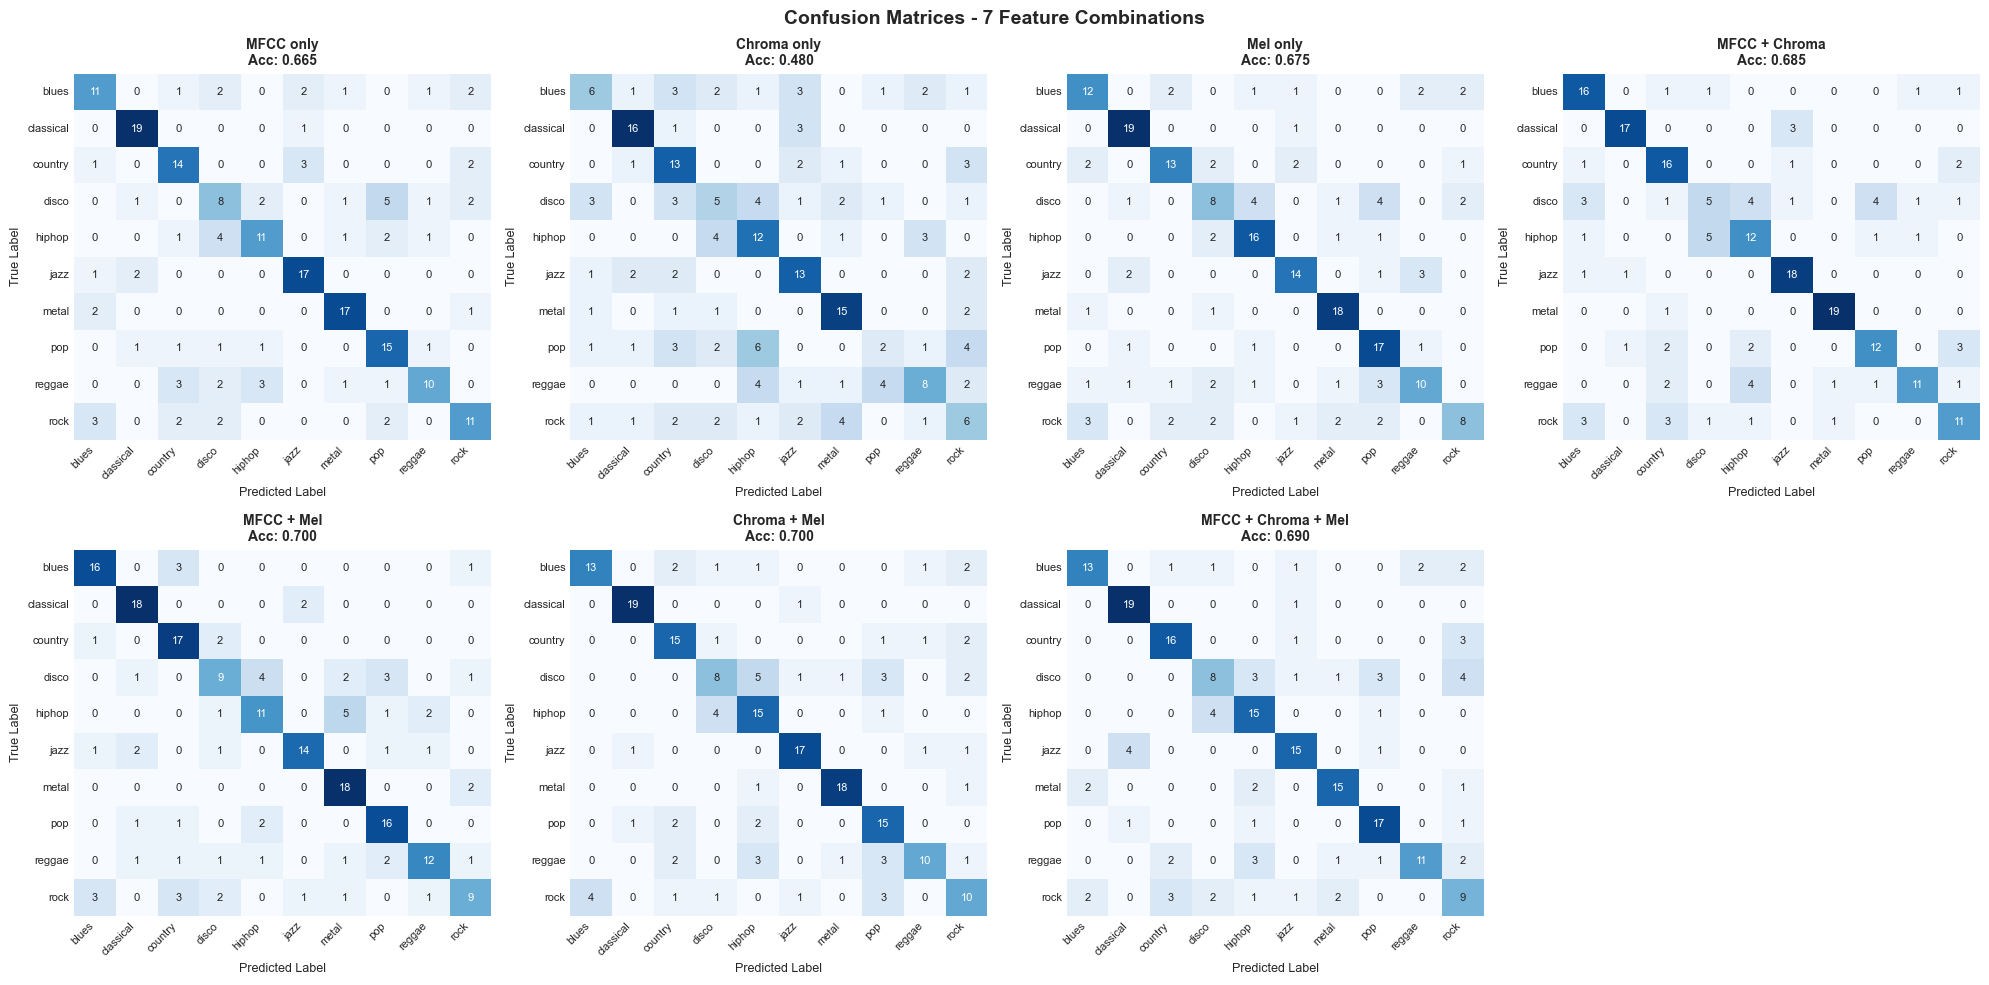

✓ Confusion matrices saved as 'comparison_01_confusion_matrices.png'


In [5]:
print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame(eval_results).T
comparison_df = comparison_df.sort_values('test_acc', ascending=False)

print("\n→ Performance Summary (sorted by Test Accuracy):")
print(comparison_df.to_string())

# Find best model
best_model = comparison_df.index[0]
best_acc = comparison_df.iloc[0]['test_acc']

print(f"\n→ Best Model: {best_model} (Test Acc: {best_acc:.4f})")

# Generate confusion matrices
print(f"\n" + "="*80)
print("GENERATING CONFUSION MATRICES")
print("="*80)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (combo_name, pred_data) in enumerate(predictions.items()):
    y_pred = pred_data['y_pred']
    y_test = pred_data['y_test']
    
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False, annot_kws={'size': 8})
    
    ax.set_title(f'{combo_name}\nAcc: {acc:.3f}', fontweight='bold', fontsize=10)
    ax.set_ylabel('True Label', fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Confusion Matrices - 7 Feature Combinations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_01_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved as 'comparison_01_confusion_matrices.png'")

## 5. Accuracy & F1-Score Comparison

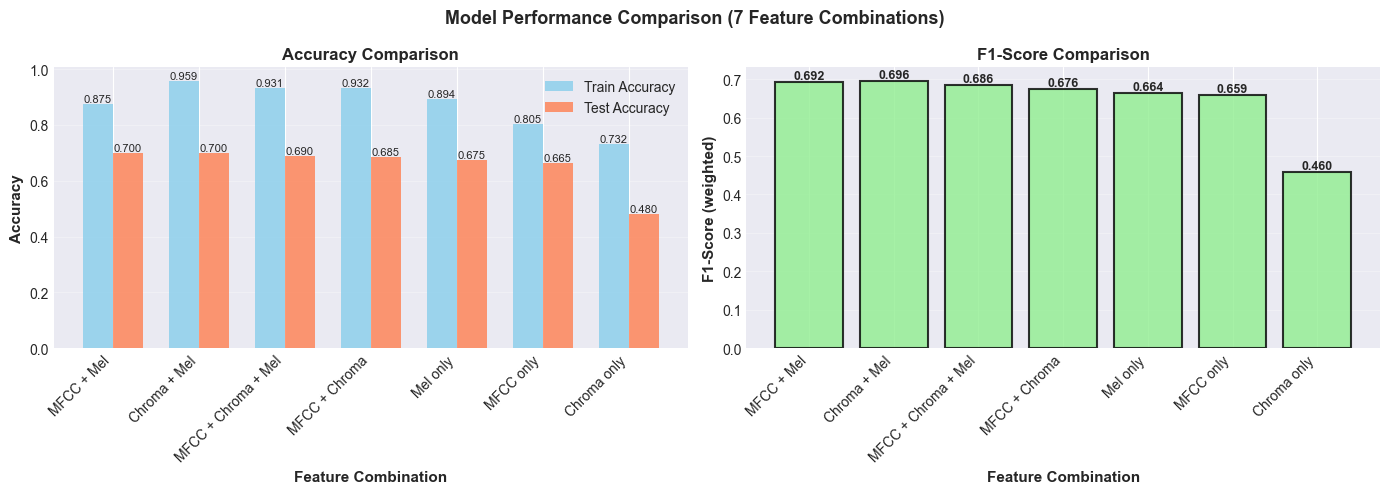

✓ Accuracy & F1-score comparison saved as 'comparison_02_accuracy_f1.png'


In [6]:
# Visualisasi perbandingan akurasi dan F1-score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax = axes[0]
combo_names = comparison_df.index
train_accs = comparison_df['train_acc'].values
test_accs = comparison_df['test_acc'].values

x = np.arange(len(combo_names))
width = 0.35

bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', alpha=0.8, color='coral')

ax.set_xlabel('Feature Combination', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(combo_names, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# F1-Score comparison
ax = axes[1]
f1_scores = comparison_df['f1_score'].values

bars = ax.bar(x, f1_scores, alpha=0.8, color='lightgreen', edgecolor='black', linewidth=1.5)

ax.set_xlabel('Feature Combination', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score (weighted)', fontsize=11, fontweight='bold')
ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(combo_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for idx, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison (7 Feature Combinations)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_02_accuracy_f1.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Accuracy & F1-score comparison saved as 'comparison_02_accuracy_f1.png'")

## 6. Per-Genre Performance Analysis


PER-GENRE PERFORMANCE ANALYSIS


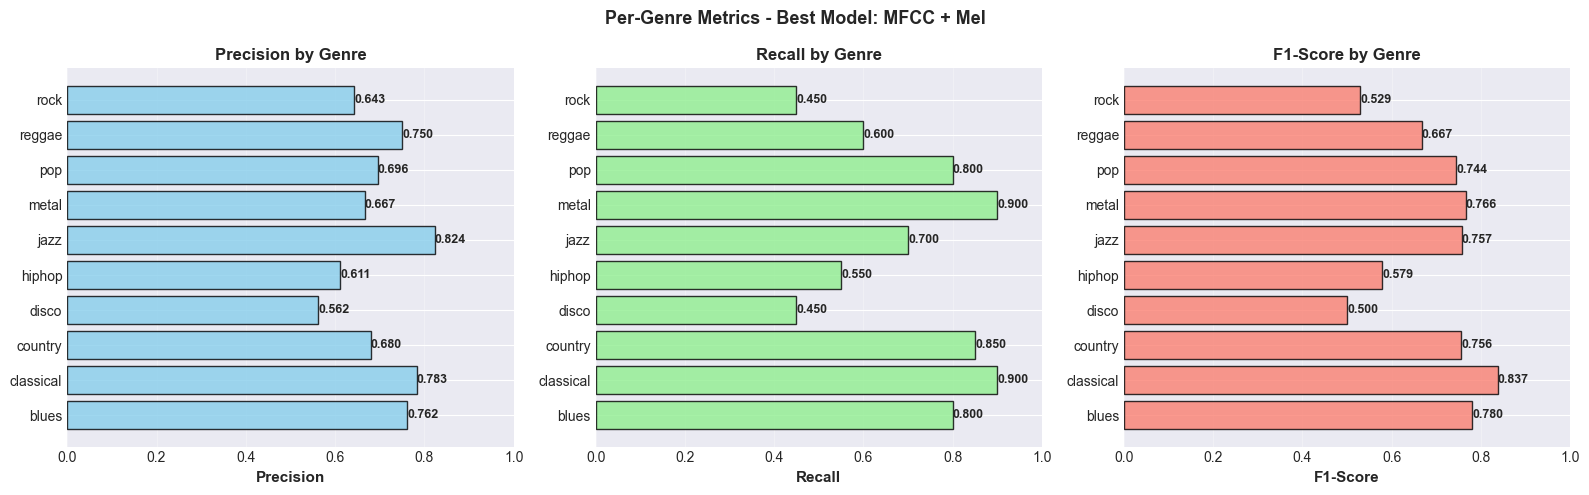


→ Best Model: MFCC + Mel

              precision    recall  f1-score   support

       blues       0.76      0.80      0.78        20
   classical       0.78      0.90      0.84        20
     country       0.68      0.85      0.76        20
       disco       0.56      0.45      0.50        20
      hiphop       0.61      0.55      0.58        20
        jazz       0.82      0.70      0.76        20
       metal       0.67      0.90      0.77        20
         pop       0.70      0.80      0.74        20
      reggae       0.75      0.60      0.67        20
        rock       0.64      0.45      0.53        20

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.70      0.69       200

✓ Per-genre analysis saved as 'comparison_03_per_genre_metrics.png'


In [7]:
print("\n" + "="*80)
print("PER-GENRE PERFORMANCE ANALYSIS")
print("="*80)

# Calculate per-genre metrics for best model
best_combo = comparison_df.index[0]
best_pred = predictions[best_combo]
y_pred_best = best_pred['y_pred']
y_test_best = best_pred['y_test']

report = classification_report(y_test_best, y_pred_best, target_names=le.classes_, output_dict=True)

genres = le.classes_
precisions = [report[g]['precision'] for g in genres]
recalls = [report[g]['recall'] for g in genres]
f1_scores_per_genre = [report[g]['f1-score'] for g in genres]

# Visualisasi per-genre metrics untuk best model
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Precision
ax = axes[0]
bars = ax.barh(genres, precisions, color='skyblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Precision', fontsize=11, fontweight='bold')
ax.set_title('Precision by Genre', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Recall
ax = axes[1]
bars = ax.barh(genres, recalls, color='lightgreen', edgecolor='black', alpha=0.8)
ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax.set_title('Recall by Genre', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# F1-Score
ax = axes[2]
bars = ax.barh(genres, f1_scores_per_genre, color='salmon', edgecolor='black', alpha=0.8)
ax.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax.set_title('F1-Score by Genre', fontsize=12, fontweight='bold')
ax.set_xlim([0, 1])
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f'{width:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Per-Genre Metrics - Best Model: {best_combo}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_03_per_genre_metrics.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n→ Best Model: {best_combo}")
print(f"\n{classification_report(y_test_best, y_pred_best, target_names=le.classes_)}")
print("✓ Per-genre analysis saved as 'comparison_03_per_genre_metrics.png'")

## 7. Training History Visualization

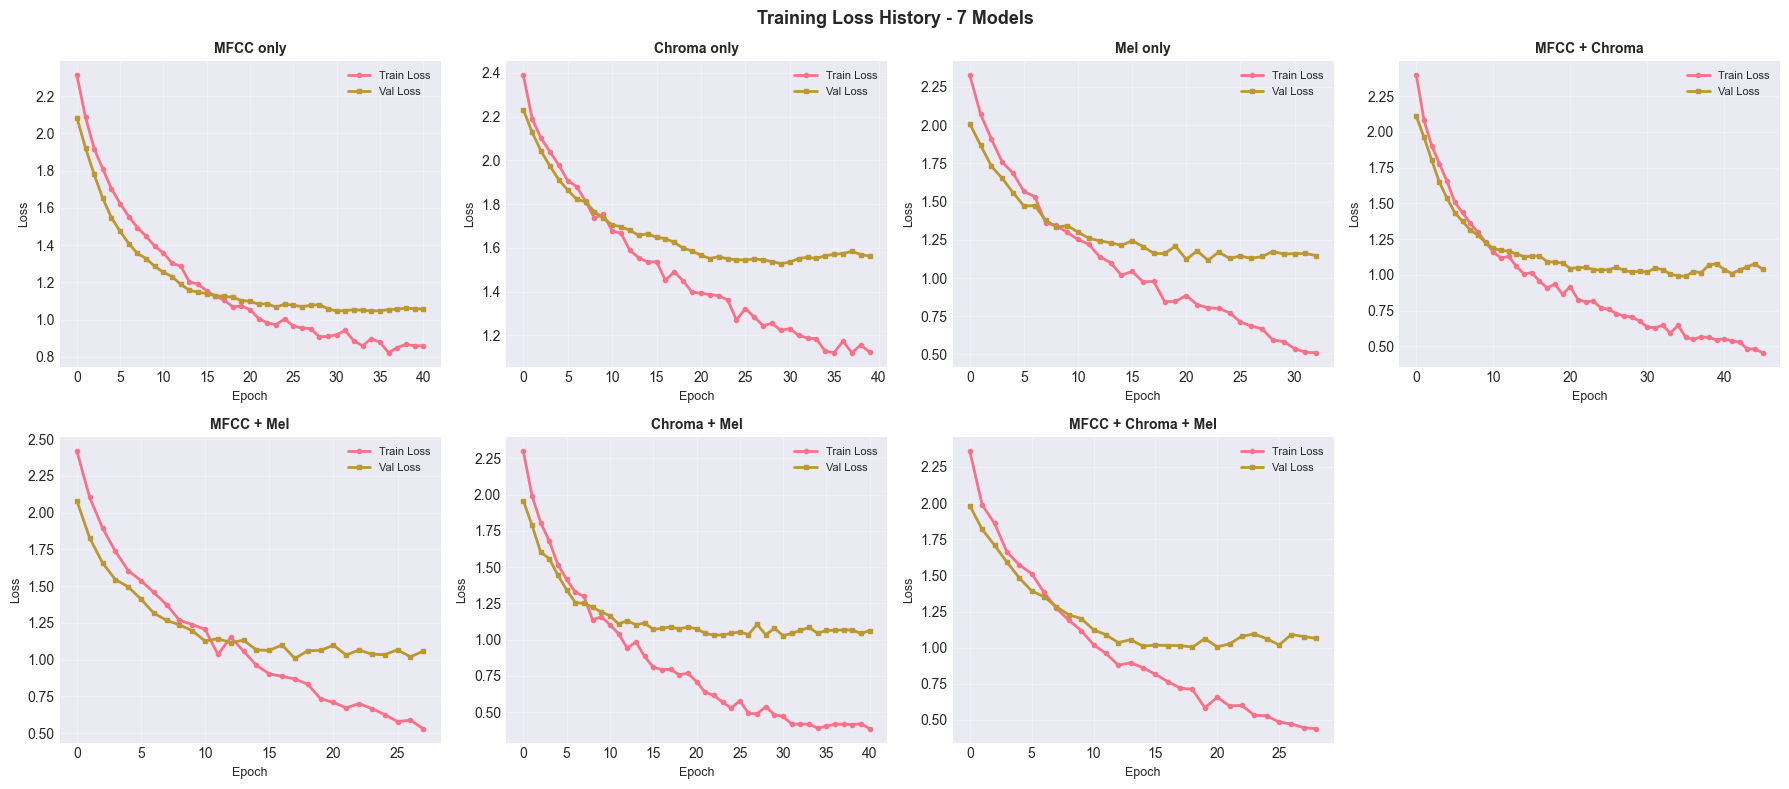

✓ Training history saved as 'comparison_04_training_history.png'


In [8]:
# Visualisasi training history untuk 7 models
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (combo_name, history) in enumerate(histories.items()):
    ax = axes[idx]
    
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
    ax.plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
    
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Loss', fontsize=9)
    ax.set_title(f'{combo_name}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Training Loss History - 7 Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_04_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Training history saved as 'comparison_04_training_history.png'")

## 8. Final Summary & Insights

In [9]:
print("\n" + "="*80)
print("FINAL SUMMARY & INSIGHTS")
print("="*80)

print(f"\n→ Model Rankings (by Test Accuracy):")
for rank, (combo_name, row) in enumerate(comparison_df.iterrows(), 1):
    print(f"{rank}. {combo_name:30} | Acc: {row['test_acc']:.4f} | F1: {row['f1_score']:.4f} | Loss: {row['test_loss']:.4f}")

# Feature importance analysis
print(f"\n→ Feature Importance Analysis:")
mfcc_only_acc = comparison_df.loc['MFCC only', 'test_acc']
chroma_only_acc = comparison_df.loc['Chroma only', 'test_acc']
mel_only_acc = comparison_df.loc['Mel only', 'test_acc']
combined_acc = comparison_df.loc['MFCC + Chroma + Mel', 'test_acc']

print(f"\n  Single Features:")
print(f"  • MFCC only:        {mfcc_only_acc:.4f}")
print(f"  • Chroma only:      {chroma_only_acc:.4f}")
print(f"  • Mel only:         {mel_only_acc:.4f}")

print(f"\n  Combined Features:")
print(f"  • MFCC + Chroma:    {comparison_df.loc['MFCC + Chroma', 'test_acc']:.4f}")
print(f"  • MFCC + Mel:       {comparison_df.loc['MFCC + Mel', 'test_acc']:.4f}")
print(f"  • Chroma + Mel:     {comparison_df.loc['Chroma + Mel', 'test_acc']:.4f}")
print(f"  • MFCC+Chroma+Mel:  {combined_acc:.4f}")

print(f"\n  Improvement (best single vs combined):")
best_single = max(mfcc_only_acc, chroma_only_acc, mel_only_acc)
improvement = ((combined_acc - best_single) / best_single) * 100
print(f"  {best_single:.4f} → {combined_acc:.4f} (+{improvement:.2f}%)")

print(f"\n→ Key Findings:")
print(f"  • Best performing model: {best_combo}")
print(f"  • Best test accuracy: {comparison_df.iloc[0]['test_acc']:.4f}")
print(f"  • Average test accuracy across 7 models: {comparison_df['test_acc'].mean():.4f}")
print(f"  • Standard deviation: {comparison_df['test_acc'].std():.4f}")

# Overfitting analysis
print(f"\n→ Overfitting Analysis:")
for combo_name in comparison_df.index:
    train_acc = eval_results[combo_name]['train_acc']
    test_acc = eval_results[combo_name]['test_acc']
    gap = train_acc - test_acc
    print(f"  {combo_name:30} | Train-Test Gap: {gap:.4f}")

print(f"\n" + "="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)


FINAL SUMMARY & INSIGHTS

→ Model Rankings (by Test Accuracy):
1. MFCC + Mel                     | Acc: 0.7000 | F1: 0.6915 | Loss: 1.0074
2. Chroma + Mel                   | Acc: 0.7000 | F1: 0.6960 | Loss: 1.0281
3. MFCC + Chroma + Mel            | Acc: 0.6900 | F1: 0.6857 | Loss: 1.0033
4. MFCC + Chroma                  | Acc: 0.6850 | F1: 0.6756 | Loss: 0.9897
5. Mel only                       | Acc: 0.6750 | F1: 0.6644 | Loss: 1.1163
6. MFCC only                      | Acc: 0.6650 | F1: 0.6588 | Loss: 1.0462
7. Chroma only                    | Acc: 0.4800 | F1: 0.4597 | Loss: 1.5284

→ Feature Importance Analysis:

  Single Features:
  • MFCC only:        0.6650
  • Chroma only:      0.4800
  • Mel only:         0.6750

  Combined Features:
  • MFCC + Chroma:    0.6850
  • MFCC + Mel:       0.7000
  • Chroma + Mel:     0.7000
  • MFCC+Chroma+Mel:  0.6900

  Improvement (best single vs combined):
  0.6750 → 0.6900 (+2.22%)

→ Key Findings:
  • Best performing model: MFCC + Mel
  •